In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [39]:
## Sample of the Data set. To understand the different features available
df = pd.read_csv('Breastcancer.xls')
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

# Importance of each aspect of a feature

1. Mean : Average of nuclei
2. SE (Standard Error): Measures the variation amongst nuclei, Higher the value the mosre likely its going to be Malignant.
3. Worst: Mean of the top 3 worst nuclei

In [41]:
## Dropping the 'id' column as the feature does not affect whethter the cell is Malignant or Benign
df.drop(['id'], axis = 1, inplace = True)
df.sample(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
294,B,12.720,13.78,81.78,492.1,0.09667,0.08393,0.01288,0.01924,0.1638,...,13.500,17.48,88.54,553.7,0.1298,0.14720,0.05233,0.06343,0.2369,0.06922
440,B,10.970,17.20,71.73,371.5,0.08915,0.11130,0.09457,0.03613,0.1489,...,12.360,26.87,90.14,476.4,0.1391,0.40820,0.47790,0.15550,0.2540,0.09532
175,B,8.671,14.45,54.42,227.2,0.09138,0.04276,0.00000,0.00000,0.1722,...,9.262,17.04,58.36,259.2,0.1162,0.07057,0.00000,0.00000,0.2592,0.07848
238,B,14.220,27.85,92.55,623.9,0.08223,0.10390,0.11030,0.04408,0.1342,...,15.750,40.54,102.50,764.0,0.1081,0.24260,0.30640,0.08219,0.1890,0.07796
445,B,11.990,24.89,77.61,441.3,0.10300,0.09218,0.05441,0.04274,0.1820,...,12.980,30.36,84.48,513.9,0.1311,0.18220,0.16090,0.12020,0.2599,0.08251


In [42]:
## Change the Diagnosis feauter to and numerical value before fitting into the model
df['diagnosis'] = [ 1 if i == "M" else 0 for i in df.diagnosis]
df.sample(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
399,0,11.80,17.26,75.26,431.9,0.09087,0.06232,0.02853,0.01638,0.1847,...,13.45,24.49,86.00,562.0,0.1244,0.1726,0.1449,0.05356,0.2779,0.08121
43,1,13.28,20.28,87.32,545.2,0.10410,0.14360,0.09847,0.06158,0.1974,...,17.38,28.00,113.10,907.2,0.1530,0.3724,0.3664,0.14920,0.3739,0.10270
347,0,14.76,14.74,94.87,668.7,0.08875,0.07780,0.04608,0.03528,0.1521,...,17.27,17.93,114.20,880.8,0.1220,0.2009,0.2151,0.12510,0.3109,0.08187
254,1,19.45,19.33,126.50,1169.0,0.10350,0.11880,0.13790,0.08591,0.1776,...,25.70,24.57,163.10,1972.0,0.1497,0.3161,0.4317,0.19990,0.3379,0.08950
195,0,12.91,16.33,82.53,516.4,0.07941,0.05366,0.03873,0.02377,0.1829,...,13.88,22.00,90.81,600.6,0.1097,0.1506,0.1764,0.08235,0.3024,0.06949


In [43]:
X = df.drop(['diagnosis'],axis = 1)
y = df.diagnosis.values

In [44]:
X_train, X_test, Y_train, Y_test = train_test_split( X, y, test_size = 0.3, random_state = 42)

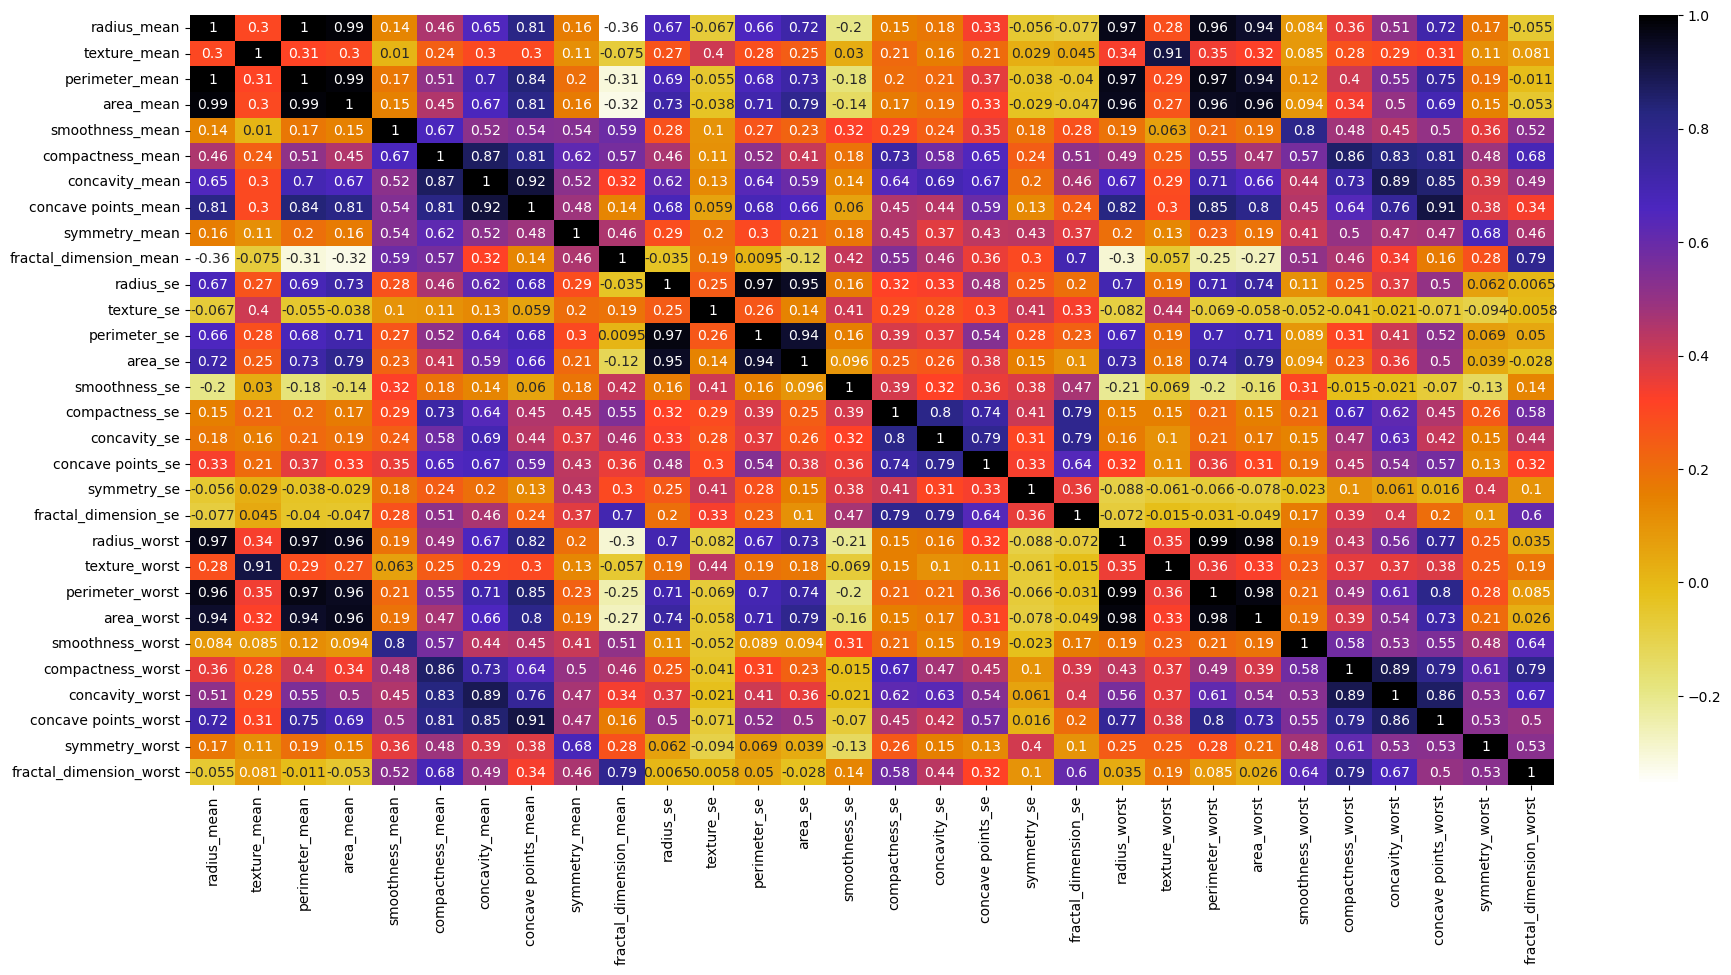

In [45]:
## Graphing the corelation plot for better understanding the different features and their relation to one another
corr = X_train.corr()
plt.figure(figsize=(22, 10))
sns.heatmap(corr,annot=True, cmap=plt.cm.CMRmap_r)
plt.show()

In [46]:
## A function made to collect the corelated features at a given threshold
def correlation(dataset,threshold):
    corr_col = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i,j] > threshold):
                colname = corr_matrix.columns[i]
                corr_col.add(colname)
    return corr_col

In [47]:
cols = correlation(X_train, 0.85)
cols

{'area_mean',
 'area_se',
 'area_worst',
 'compactness_worst',
 'concave points_mean',
 'concave points_worst',
 'concavity_mean',
 'concavity_worst',
 'perimeter_mean',
 'perimeter_se',
 'perimeter_worst',
 'radius_worst',
 'texture_worst'}

## Reasons to drop the corelated feature:

1. **area_mean** : Area here is calculated by the mean summation of all areas with different raduises. The cell is not particularly ciricle so the raduis is not consistent. If the raduis is higher the area would also be high, hence dropping this column would be beneficial.
2. **area_worst** : Represents the average of the three largest nucleus areas in the sample. This does not help in classifying whether the cell is cancerous or not.
3. **Compactness_worst** : Compactness is derieved from Perimeter sqaure by area subtracted by 1. This means the feature is highly corelated to the features area and perimeter. Compactness does not really provide any additional independent information to model.
4. **concave points_worst** : We already are using the Concave points_mean feauture as the indicatior for whether the cell is malignant or benign. So have the mean of the worst points wont provide addtional indenpent importance towrds the classification.
5. **Concavity_mean** : This feature provides the mean depth of the concave points in the cell. This is not being considred as it is highly corelted with the concavity_worst and would not provide any addional information.


## Reason to not drop the corelated feature:
1. **area_se** : This column shows how the individual nuclei areas compare to the mean area. This varience could play an important role in identifying the potential outliers in the feature.
2. **concave points_mean** : This column gives usa count of the whether the cell has an inward curve. This is a feature which could propely classify whether the cell is Malignant or Benign.
3. **Concavity_worst** : This feature provides the mean of the top three depths of the concave points in the cell. This is a highly corelated feautre with the concave points worst but it provides a certain threshold to which I believe would help the model classify better.
4. **Perimeter_se and perimeter_worst** : These features are provide a good threshold for the perimeter of the cell. I feel having them in the training dataset would be more benefitial than the perimeter_mean feature.
5. **radius_worst** : This features provides the largest and most deformed nuclei, a strong indicator of malignancy.

In [48]:
## Dropping the columns from the training and testing dataframes, making them more effiecient and stops overfitting.
X_train.drop(['area_mean','area_worst','compactness_worst','concave points_worst','concavity_mean'],axis=1,inplace =True)
X_test.drop(['area_mean','area_worst','compactness_worst','concave points_worst','concavity_mean'],axis=1,inplace=True)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
model = LogisticRegression()
model.fit(X_train_scaled,Y_train)
y_pred = model.predict(X_test_scaled)

In [51]:
df_compare = pd.DataFrame({'Diagnosis Real':Y_test,'Diagnosis Prediction':y_pred})
df_compare

,Diagnosis Real,Diagnosis Prediction
0,0,0
1,1,1
2,1,1
3,0,0
4,0,0
...,...,...
166,0,0
167,0,0
168,0,0
169,1,1


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall    = recall_score(Y_test, y_pred)
f1        = f1_score(Y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9883040935672515
Precision: 0.9841269841269841
Recall   : 0.9841269841269841
F1 Score : 0.9841269841269841


In [53]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get probabilities for the positive class
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# AUC score
auc = roc_auc_score(Y_test, y_probs)
print("ROC AUC:", auc)

ROC AUC: 0.9973544973544973


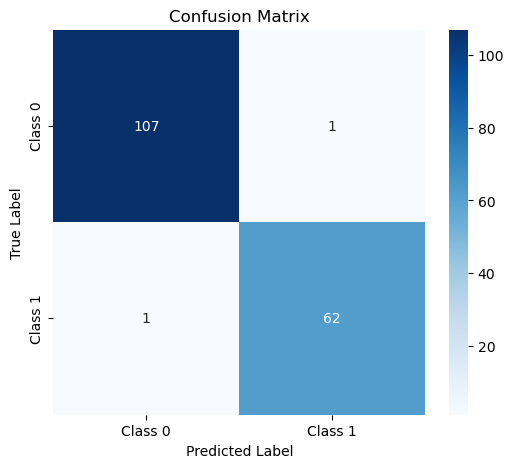

In [54]:
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()